In [ ]:
# ================================================
# Image Segmentation Assignment - 5 Classes
# Classes: 0=background, 1=person, 2=car, 3=book, 4=airplane
# ================================================

# 1. Setup
!pip install -q segmentation-models-pytorch albumentations torchmetrics pycocotools

In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import defaultdict
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from torchmetrics import JaccardIndex
import albumentations as A
from albumentations.pytorch import ToTensorV2
import random
from tqdm import tqdm
from pycocotools import mask as maskUtils

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

Device: cuda


In [ ]:
# 2. Paths
BASE_DIR = './RMDS_segmentation_dataset_ADE20K_350'
TRAIN_DIR = f'{BASE_DIR}/train'
VAL_DIR = f'{BASE_DIR}/val'
TEST_DIR = f'{BASE_DIR}/test'
TRAIN_JSON = f'{BASE_DIR}/instances_train.json'
VAL_JSON = f'{BASE_DIR}/instances_val.json'

# ADE20K class id -> our class id mapping
# person=4 -> 1, car=9 -> 2, book=40 -> 3, airplane=59 -> 4
CLASS_MAPPING = {4: 1, 9: 2, 40: 3, 59: 4}
NUM_CLASSES = 5  # background + 4

In [ ]:
# 3. Helper: Load COCO JSON and build per-image mask generator

def load_annotations(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)

    # image_id -> file_name, width, height
    img_info = {}
    for img in data['images']:
        img_info[img['id']] = img

    # group annotations by image_id
    anns_by_img = defaultdict(list)
    for ann in data['annotations']:
        anns_by_img[ann['image_id']].append(ann)

    return img_info, anns_by_img


def build_mask(image_id, img_info, anns_by_img, height, width):
    """Build 5-class mask (0=background, 1-4=classes) for given image."""
    mask = np.zeros((height, width), dtype=np.uint8)
    img = img_info.get(image_id)
    if img is None:
        return mask
    for ann in anns_by_img.get(image_id, []):
        ade_id = ann['category_id']
        our_id = CLASS_MAPPING.get(ade_id)
        if our_id is not None:
            rle = ann['segmentation']
            if isinstance(rle, dict):
                rle['size'] = [height, width]
                decoded = maskUtils.decode(rle)
                mask[decoded > 0] = our_id
    return mask

In [ ]:
# 4. Custom Dataset

class ADE20K4ClassDataset(Dataset):
    def __init__(self, image_dir, img_info, anns_by_img, transform=None, is_test=False):
        self.image_dir = image_dir
        self.transform = transform
        self.is_test = is_test
        self.img_info = img_info
        self.anns_by_img = anns_by_img
        self.images = sorted([f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png'))])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.image_dir, img_name)

        image = np.array(Image.open(img_path).convert('RGB'))
        h, w = image.shape[:2]

        if self.is_test:
            mask = np.zeros((h, w), dtype=np.uint8)
        else:
            # find image_id by matching file_name
            image_id = None
            for iid, info in self.img_info.items():
                if info['file_name'] == img_name:
                    image_id = iid
                    break
            if image_id is not None:
                mask = build_mask(image_id, self.img_info, self.anns_by_img, h, w)
            else:
                mask = np.zeros((h, w), dtype=np.uint8)

        if self.transform:
            if self.is_test:
                transformed = self.transform(image=image)
                image = transformed['image']
            else:
                transformed = self.transform(image=image, mask=mask)
                image = transformed['image']
                mask = transformed['mask']

        if self.is_test:
            return image, img_name
        # mask is already a Tensor from ToTensorV2, or np.ndarray if no transform
        if isinstance(mask, np.ndarray):
            mask = torch.from_numpy(mask).long()
        else:
            mask = mask.long()
        return image, mask

In [ ]:
# 5. Augmentations

train_transform = A.Compose([
    A.Resize(512, 512),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),
    A.GaussNoise(var_limit=(10, 50), p=0.3),
    A.CoarseDropout(max_holes=4, max_height=32, max_width=32, fill_value=0, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

c:\Users\Salman\miniconda3\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\Salman\AppData\Local\Temp\ipykernel_9332\1184523658.py:9: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.3),
C:\Users\Salman\AppData\Local\Temp\ipykernel_9332\1184523658.py:10: UserWarning: Argument(s) 'max_holes, max_height, max_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=32, max_width=32, fill_value=0, p=0.3),


In [ ]:
# 6. Create Datasets & Loaders

train_img_info, train_anns = load_annotations(TRAIN_JSON)
val_img_info, val_anns = load_annotations(VAL_JSON)

train_dataset = ADE20K4ClassDataset(TRAIN_DIR, train_img_info, train_anns, transform=train_transform)
val_dataset = ADE20K4ClassDataset(VAL_DIR, val_img_info, val_anns, transform=val_transform)
test_dataset = ADE20K4ClassDataset(TEST_DIR, None, None, transform=val_transform, is_test=True)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)} images, Val: {len(val_dataset)} images, Test: {len(test_dataset)} images")

Train: 350 images, Val: 350 images, Test: 30 images


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7582841..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.3153813].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.552854].


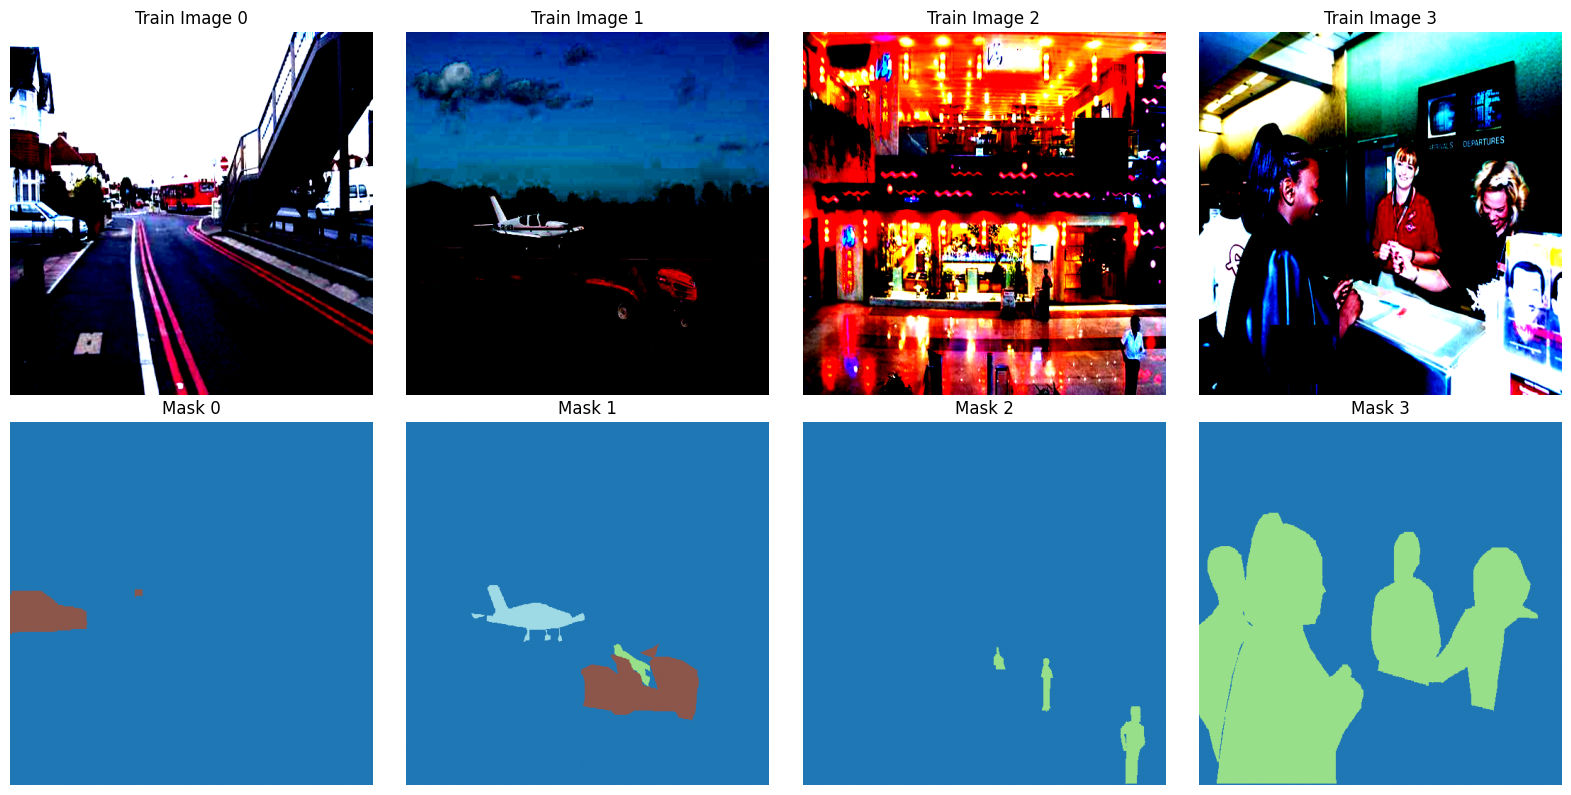

Class distribution in train set (first 50 images):
  0 (background): 11971454 pixels (91.33%)
  1 (person): 934255 pixels (7.13%)
  2 (car): 165534 pixels (1.26%)
  3 (book): 24399 pixels (0.19%)
  4 (airplane): 11558 pixels (0.09%)


In [ ]:
# 7. EDA - Visualize samples

def show_eda():
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for i in range(4):
        img, mask = train_dataset[i]
        axes[0, i].imshow(img.permute(1, 2, 0).cpu().numpy())
        axes[0, i].set_title(f"Train Image {i}")
        axes[0, i].axis('off')
        axes[1, i].imshow(mask.cpu().numpy(), cmap='tab20', vmin=0, vmax=4)
        axes[1, i].set_title(f"Mask {i}")
        axes[1, i].axis('off')
    plt.tight_layout()
    plt.show()

    # Class distribution
    all_masks = []
    for i in range(min(50, len(train_dataset))):
        _, m = train_dataset[i]
        all_masks.append(m.numpy().flatten())
    all_masks = np.concatenate(all_masks)
    total_pixels = len(all_masks)
    classes, counts = np.unique(all_masks, return_counts=True)
    print("Class distribution in train set (first 50 images):")
    names = ['background', 'person', 'car', 'book', 'airplane']
    class_weights = np.zeros(NUM_CLASSES)
    for c, cnt in zip(classes, counts):
        pct = cnt / total_pixels * 100
        class_weights[c] = total_pixels / (NUM_CLASSES * cnt) if cnt > 0 else 1.0
        print(f"  {c} ({names[c]}): {cnt} pixels ({pct:.2f}%)")
    return class_weights

class_weights_from_eda = show_eda()

In [ ]:
# 8. Combined Loss (Dice + Focal)

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
    def forward(self, logits, targets):
        probs = torch.softmax(logits, dim=1)
        targets_onehot = torch.nn.functional.one_hot(targets, num_classes=NUM_CLASSES).permute(0, 3, 1, 2).float()
        intersection = (probs * targets_onehot).sum(dim=(2, 3))
        union = probs.sum(dim=(2, 3)) + targets_onehot.sum(dim=(2, 3))
        dice = (2.0 * intersection + self.smooth) / (union + self.smooth)
        return 1.0 - dice.mean()

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
    def forward(self, logits, targets):
        ce_loss = nn.functional.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma * ce_loss).mean()
        return focal_loss

class CombinedLoss(nn.Module):
    def __init__(self, alpha, gamma=2.0):
        super().__init__()
        self.dice = DiceLoss()
        self.focal = FocalLoss(gamma=gamma, alpha=alpha)
    def forward(self, logits, targets):
        return self.dice(logits, targets) + self.focal(logits, targets)

# Compute class weights from EDA or use inverse frequency
class_weights = torch.tensor([
    0.15,  # background
    1.0,   # person
    1.0,   # car
    2.0,   # book (rare)
    3.0,   # airplane (very rare)
]).to(device)

# 9. Model with stronger backbone
model = smp.Unet(
    encoder_name="efficientnet-b3",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES,
    activation=None,
    decoder_attention_type="scse",
)
model = model.to(device)

# Enable mixed precision for faster training (if available)
from contextlib import nullcontext
use_amp = device.type == "cuda"
scaler = torch.cuda.amp.GradScaler() if use_amp else None
autocast = torch.cuda.amp.autocast() if use_amp else nullcontext()

criterion = CombinedLoss(alpha=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40, eta_min=1e-6)
metric = JaccardIndex(task="multiclass", num_classes=NUM_CLASSES).to(device)

# 10. Training Loop
def train_epoch(model, loader):
    model.train()
    total_loss = 0
    for images, masks in tqdm(loader, desc="Training"):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()

        if scaler:
            with autocast:
                outputs = model(images)
                loss = criterion(outputs, masks)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        total_loss += loss.item()
    return total_loss / len(loader)

def validate(model, loader, per_class=False):
    model.eval()
    total_loss = 0
    total_iou = 0
    per_class_iou = torch.zeros(NUM_CLASSES, device=device)
    per_class_counts = torch.zeros(NUM_CLASSES, device=device)

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Validating"):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            total_iou += metric(preds, masks).item()

            if per_class:
                for c in range(NUM_CLASSES):
                    pred_c = (preds == c)
                    mask_c = (masks == c)
                    intersection = (pred_c & mask_c).sum().float()
                    union = (pred_c | mask_c).sum().float()
                    if union > 0:
                        per_class_iou[c] += (intersection / union)
                        per_class_counts[c] += 1

    avg_loss = total_loss / len(loader)
    avg_iou = total_iou / len(loader)

    if per_class:
        avg_per_class = per_class_iou / per_class_counts.clamp(min=1)
        return avg_loss, avg_iou, avg_per_class
    return avg_loss, avg_iou

# 11. Train
EPOCHS = 40
best_iou = 0.0
patience = 8
patience_counter = 0
class_names = ['background', 'person', 'car', 'book', 'airplane']

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader)
    val_loss, val_iou, per_class = validate(model, val_loader, per_class=True)
    scheduler.step()

    per_class_str = ', '.join([f"{n}: {v:.3f}" for n, v in zip(class_names, per_class.cpu().numpy())])
    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val mIoU: {val_iou:.4f}")
    print(f"  Per-class IoU: {per_class_str}")

    if val_iou > best_iou:
        best_iou = val_iou
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_iou': best_iou,
        }, 'unet_4class_best.pth')
        print(f"  -> New best model saved (mIoU: {val_iou:.4f}) \u2713")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break

torch.save(model.state_dict(), 'unet_4class_final.pth')
print(f"\nTraining complete! Best val mIoU: {best_iou:.4f}")

c:\Users\Salman\miniconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Salman\.cache\huggingface\hub\models--smp-hub--efficientnet-b3.imagenet. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
C:\Users\Salman\AppData\Local\Temp\ipykernel_9332\3923157823.py:57: FutureWarning: `torch.cuda.amp.GradScale

Epoch 1/40 - Train Loss: 1.0121, Val Loss: 0.9332, Val mIoU: 0.1437
  Per-class IoU: background: 0.260, person: 0.177, car: 0.277, book: 0.005, airplane: 0.001
  -> New best model saved (mIoU: 0.1437) ✓


Validating: 100%|██████████| 44/44 [00:10<00:00,  4.37it/s]


Epoch 2/40 - Train Loss: 0.9048, Val Loss: 0.8503, Val mIoU: 0.3167
  Per-class IoU: background: 0.897, person: 0.370, car: 0.316, book: 0.001, airplane: 0.001
  -> New best model saved (mIoU: 0.3167) ✓


Validating: 100%|██████████| 44/44 [00:09<00:00,  4.45it/s]


...

Epoch 31/40 - Train Loss: 0.6590, Val Loss: 0.7377, Val mIoU: 0.4771
  Per-class IoU: background: 0.963, person: 0.603, car: 0.493, book: 0.088, airplane: 0.024


Validating: 100%|██████████| 44/44 [00:09<00:00,  4.67it/s]


Epoch 32/40 - Train Loss: 0.6566, Val Loss: 0.7338, Val mIoU: 0.4739
  Per-class IoU: background: 0.962, person: 0.598, car: 0.499, book: 0.090, airplane: 0.028


Validating: 100%|██████████| 44/44 [00:08<00:00,  5.28it/s]


Epoch 33/40 - Train Loss: 0.6584, Val Loss: 0.7406, Val mIoU: 0.4792
  Per-class IoU: background: 0.964, person: 0.603, car: 0.506, book: 0.091, airplane: 0.030
Early stopping triggered after 33 epochs

Training complete! Best val mIoU: 0.4951


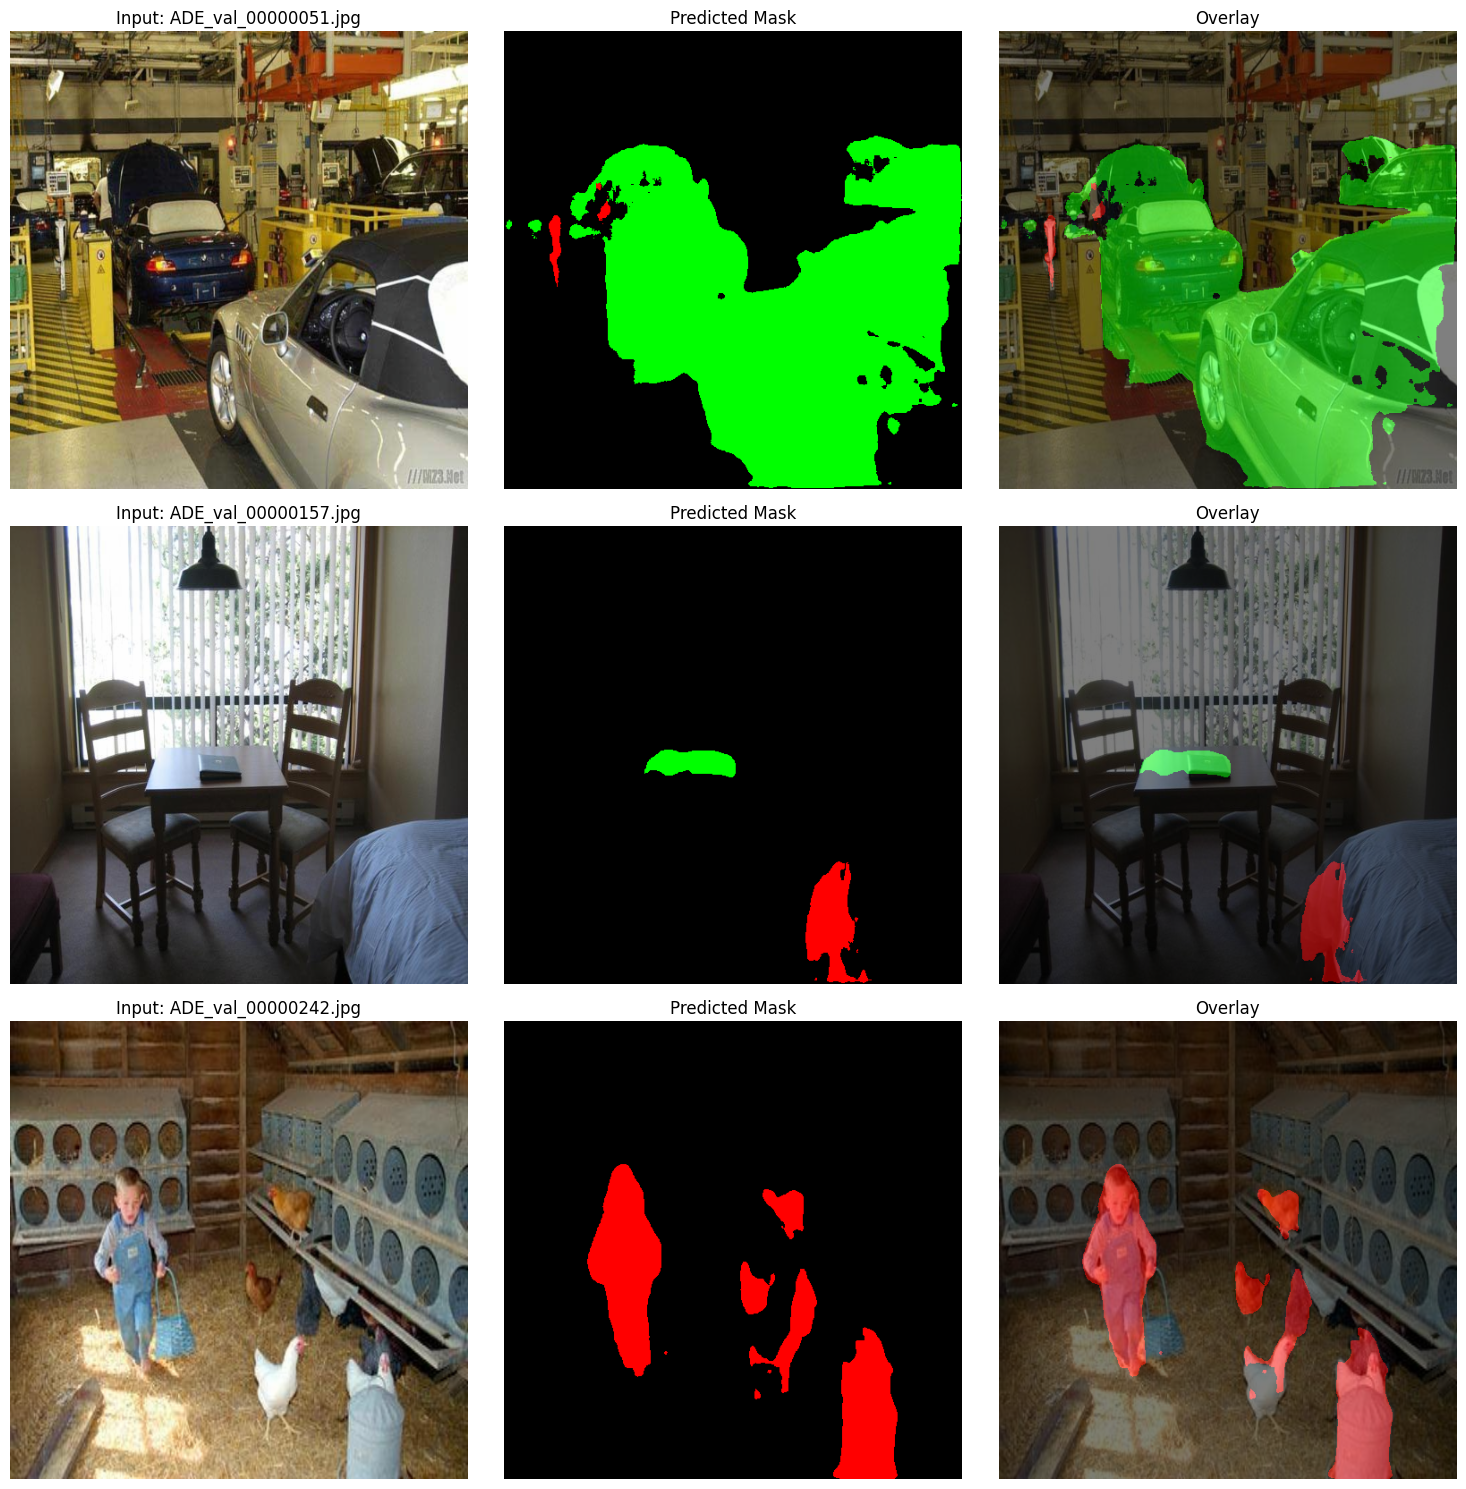


Assignment complete! Files saved:
  - unet_4class_best.pth (best checkpoint by val mIoU)
  - unet_4class_final.pth (final checkpoint)


In [ ]:
# 12. Inference on Test Images

COLORMAP = np.array([
    [0, 0, 0],       # background - black
    [255, 0, 0],     # person - red
    [0, 255, 0],     # car - green
    [0, 0, 255],     # book - blue
    [255, 255, 0],   # airplane - yellow
], dtype=np.uint8)

def visualize_predictions(model, test_dataset):
    model.eval()
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

    fig, axes = plt.subplots(3, 3, figsize=(15, 15))

    with torch.no_grad():
        for i, (images, names) in enumerate(test_loader):
            if i >= 3:
                break
            images = images.to(device)
            outputs = model(images)
            pred = torch.argmax(outputs, dim=1).cpu().numpy()[0]

            # Denormalize image for display
            img = images[0].cpu().permute(1, 2, 0).numpy()
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img = std * img + mean
            img = np.clip(img, 0, 1)

            # Colorize prediction
            pred_rgb = COLORMAP[pred]
            overlay = img * 0.5 + pred_rgb / 255.0 * 0.5

            axes[i, 0].imshow(img)
            axes[i, 0].set_title(f"Input: {names[0]}")
            axes[i, 0].axis('off')

            axes[i, 1].imshow(pred_rgb)
            axes[i, 1].set_title("Predicted Mask")
            axes[i, 1].axis('off')

            axes[i, 2].imshow(overlay)
            axes[i, 2].set_title("Overlay")
            axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

visualize_predictions(model, test_dataset)

print("\nAssignment complete! Files saved:")
print("  - unet_4class_best.pth (best checkpoint by val mIoU)")
print("  - unet_4class_final.pth (final checkpoint)")